# Lab: Regression Trees with scikit-learn

In the [theory notes](./11_regression_trees_theory.md), we learned that a Regression Tree predicts a **continuous** target by recursively partitioning the feature space into regions where target values are as similar as possible. Each leaf predicts the **mean** of the training targets that fall into it. In the [implementation file](./12_regression_trees_implementation.py), we built one from scratch using weighted MSE as the splitting criterion.

**Now it's time to use the real thing.** scikit-learn's `DecisionTreeRegressor` handles all the splitting, pruning, and prediction logic for us. In this lab, we will learn how to:

1. Load and explore a regression dataset.
2. Build and train a `DecisionTreeRegressor`.
3. Understand key hyperparameters (`max_depth`, `min_samples_leaf`, `criterion`).
4. **Visualize the tree** and the step-function predictions it produces.
5. Inspect feature importances.
6. See how different depths change the fit (underfitting → overfitting).
7. Demonstrate the **limited extrapolation** property of regression trees.

---

## 1. The Dataset

We'll use the **California Housing** dataset — a classic regression benchmark where the goal is to predict the **median house value** (in $100,000s) for California districts based on census features.

Regression trees are a natural fit because:
- Housing prices have **non-linear** relationships with features (e.g., income, location).
- Trees don't require feature scaling.
- The tree structure can reveal **interpretable thresholds** (e.g., "median income > 4.5 → higher value region").

Let's start by importing our libraries and loading the data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the California Housing dataset
housing = fetch_california_housing()

# Create a clean DataFrame
feature_names = list(housing.feature_names)
df = pd.DataFrame(housing.data, columns=feature_names)
df["MedHouseVal"] = housing.target

print(f"Dataset: {df.shape[0]:,} samples, {len(feature_names)} features")
print(f"Target: MedHouseVal (median house value in $100,000s)")
print(f"\nFeatures: {feature_names}")
print()
df.head()

Dataset: 20,640 samples, 8 features
Target: MedHouseVal (median house value in $100,000s)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


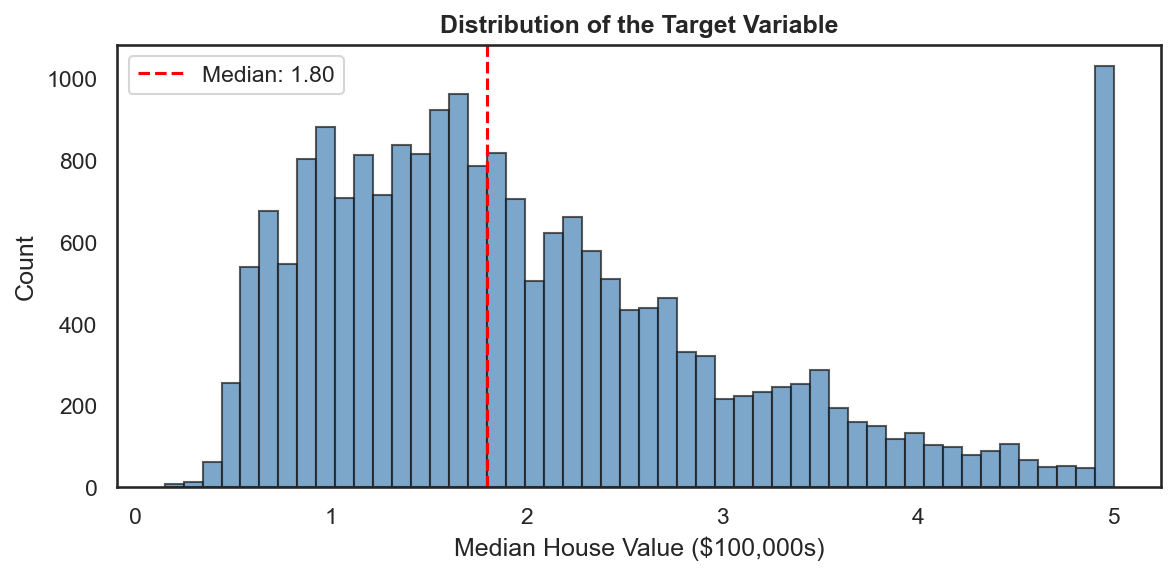

Target range: [0.150, 5.000]
Note: Values are capped at 5.001 — this is a known ceiling in the dataset.


In [3]:
# Quick look at the target distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["MedHouseVal"], bins=50, edgecolor="k", alpha=0.7, color="steelblue")
ax.set_xlabel("Median House Value ($100,000s)")
ax.set_ylabel("Count")
ax.set_title("Distribution of the Target Variable", fontweight="bold")
ax.axvline(df["MedHouseVal"].median(), color="red", linestyle="--", label=f'Median: {df["MedHouseVal"].median():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Target range: [{df['MedHouseVal'].min():.3f}, {df['MedHouseVal'].max():.3f}]")
print(f"Note: Values are capped at 5.001 — this is a known ceiling in the dataset.")

---

## 2. Preparing the Data

We separate features from the target. As with the classification decision tree in the previous lab, **no feature scaling is needed** — regression trees split on thresholds, not on distances or magnitudes.

> 📌 **No StandardScaler needed!** Regression trees are invariant to monotonic transformations of features. Whether income is measured in dollars or thousands of dollars, the tree finds the same splits.

In [4]:
# Separate features and target — no scaling needed for decision trees
X = df[feature_names].values
y = df["MedHouseVal"].values

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (20640, 8)
Shape of y: (20640,)


---

## 3. Building a Regression Tree

The `DecisionTreeRegressor` API mirrors the classifier we used in the previous lab. The key difference is:
- **Classification trees** split to minimize **Gini impurity** (or entropy) and predict the **majority class**.
- **Regression trees** split to minimize **MSE** (or MAE/Friedman MSE) and predict the **mean target value** at each leaf.

Key parameters:

| Parameter | What It Does | Default |
|---|---|---|
| `criterion` | The error measure for splitting (`"squared_error"`, `"absolute_error"`, `"friedman_mse"`) | `"squared_error"` |
| `max_depth` | Maximum depth of the tree | `None` (unlimited) |
| `min_samples_split` | Minimum samples needed to split a node | `2` |
| `min_samples_leaf` | Minimum samples required in a leaf | `1` |
| `random_state` | Seed for reproducibility | `None` |

Let's start with a constrained tree (`max_depth=3`) so we can visualize and interpret it easily:

In [5]:
# Build a Regression Tree with max_depth=3 for interpretability
reg = DecisionTreeRegressor(max_depth=3, random_state=42)
reg.fit(X, y)

print("Regression Tree trained!")
print(f"Tree depth: {reg.get_depth()}")
print(f"Number of leaves: {reg.get_n_leaves()}")
print(f"Number of features used: {reg.n_features_in_}")
print(f"Splitting criterion: {reg.criterion}")

Regression Tree trained!
Tree depth: 3
Number of leaves: 8
Number of features used: 8
Splitting criterion: squared_error


---

## 4. Visualizing the Tree

Just like classification trees, regression trees can be visualized as a flowchart. Each node now shows:
- The **splitting rule** (e.g., `MedInc <= 5.029`)
- The **squared_error** (MSE — how spread out the target values are in this node)
- The **sample count** (how many training samples reached this node)
- The **value** (the mean target value — this is the prediction if this were a leaf)

### 4.1. Graphical Tree Plot

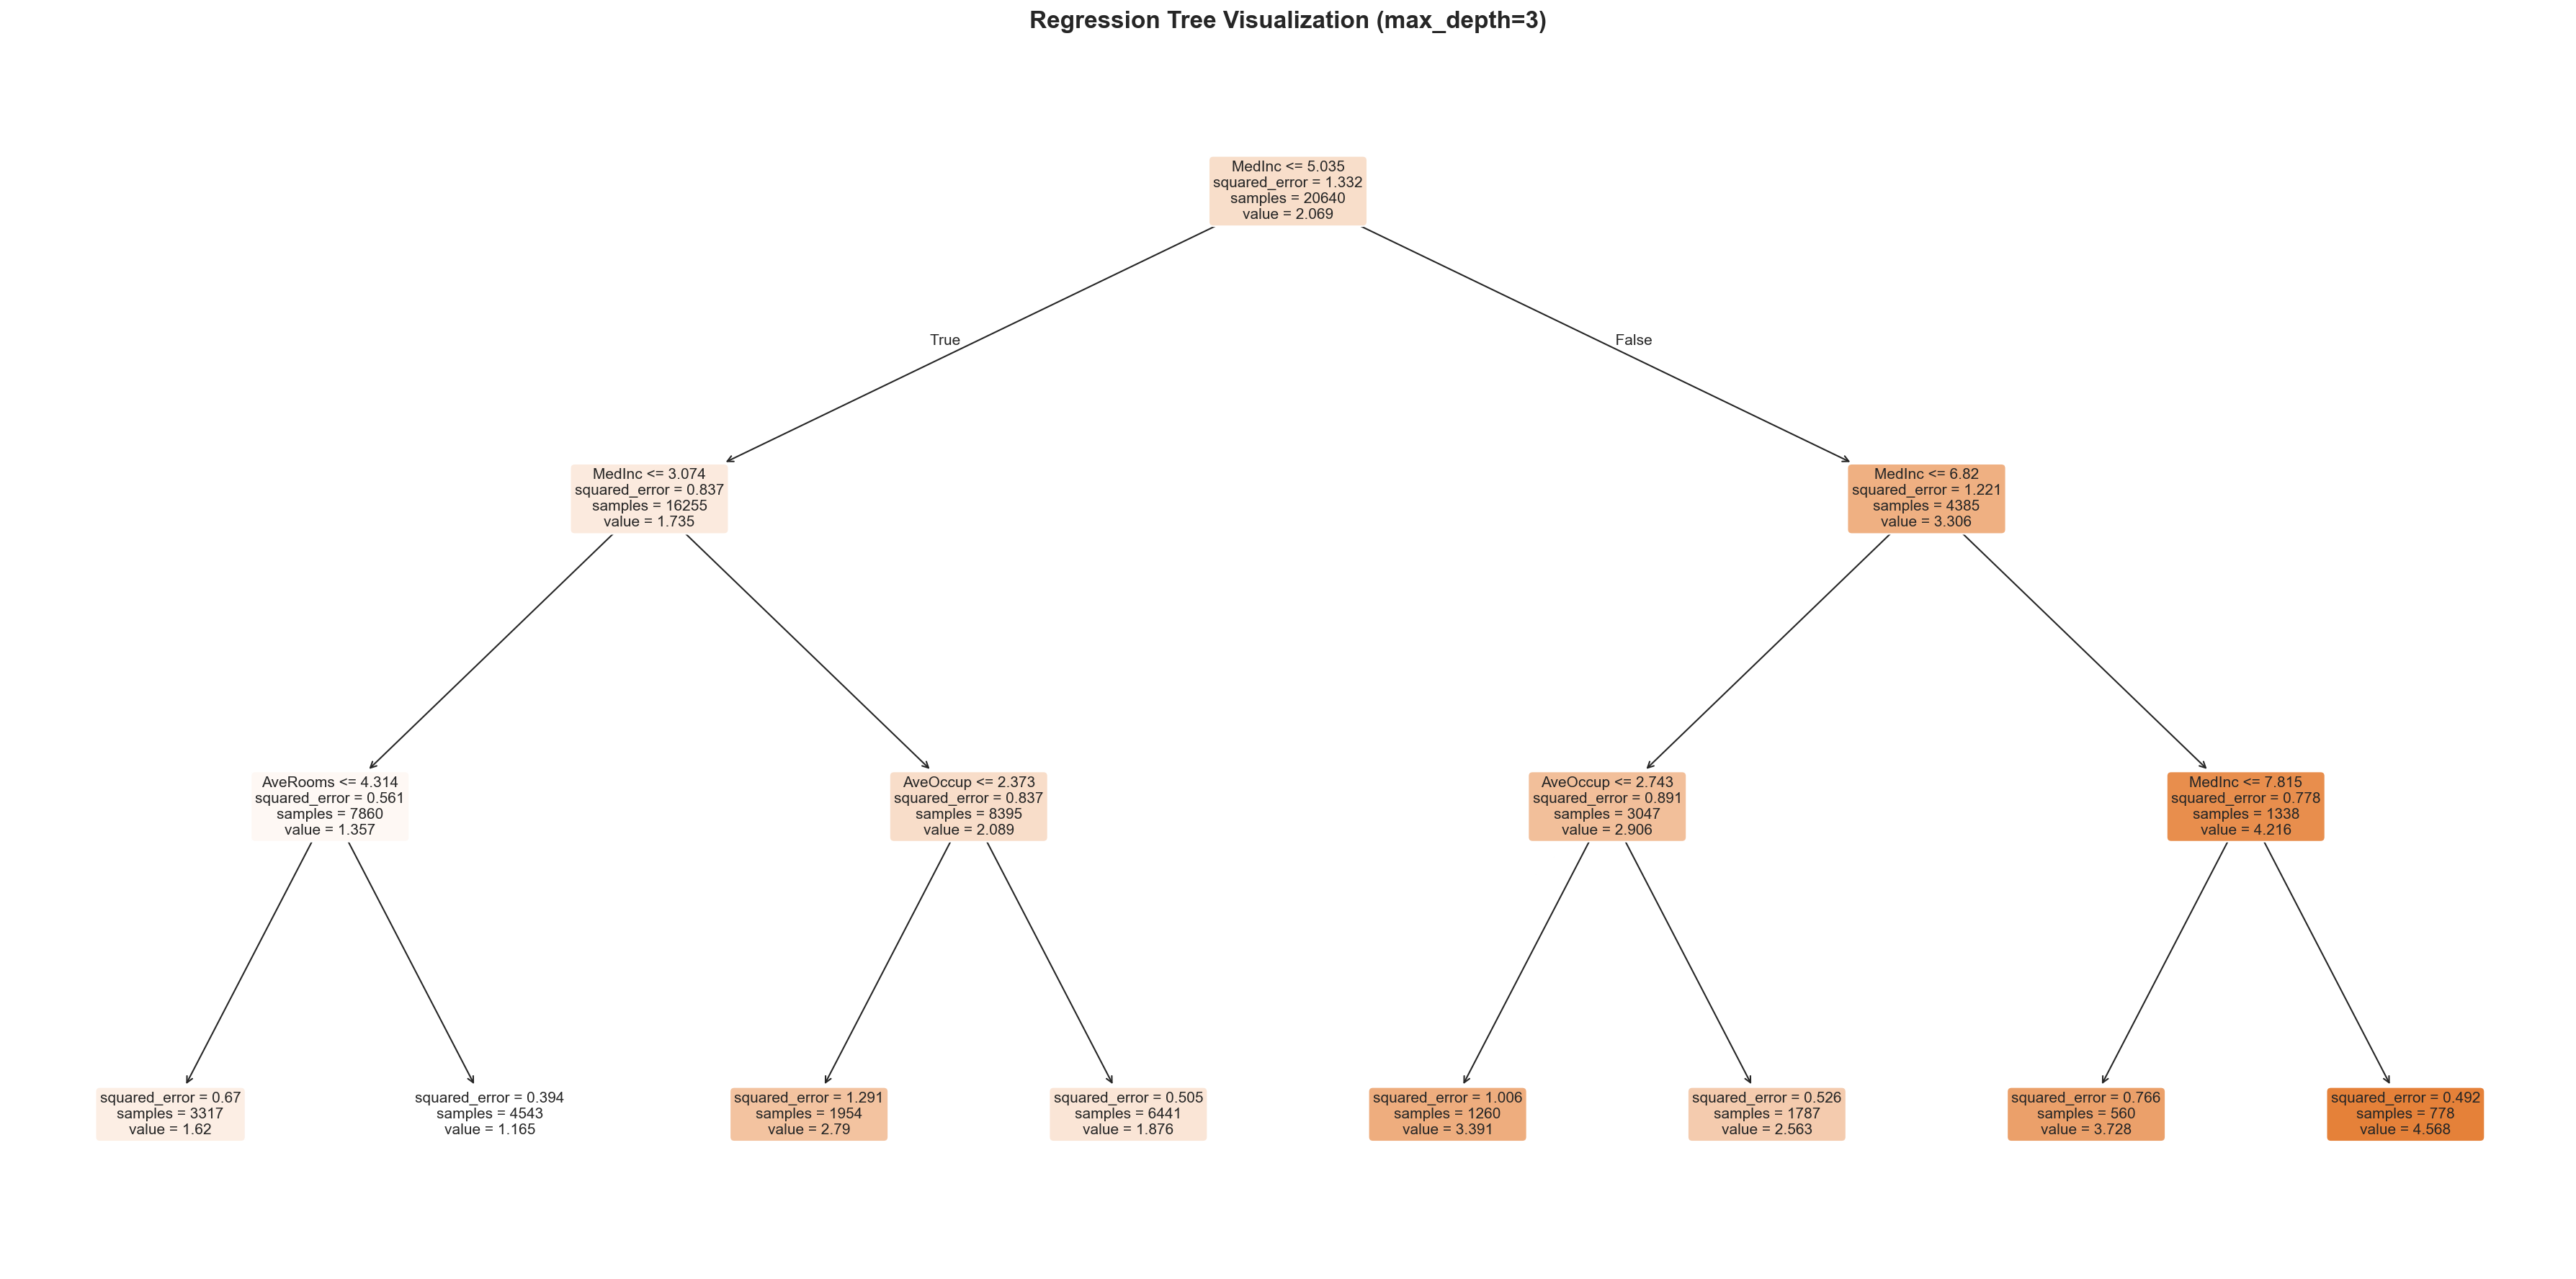

In [6]:
plt.figure(figsize=(24, 12))
plot_tree(
    reg,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True,
    proportion=False
)
plt.title("Regression Tree Visualization (max_depth=3)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 📌 How to Read the Regression Tree

1. **Start at the root** — the first split is on `MedInc` (median income). This makes intuitive sense: income is the strongest predictor of house value.
2. **Follow left** if the condition is `True` (≤ threshold), **right** if `False` (> threshold).
3. **`value`** at each node is the **mean** of the target values of all samples in that node. This is the leaf prediction formula from the theory: $\hat{y}_{\text{node}} = \frac{1}{N} \sum y^{(i)}$
4. **`squared_error`** shows the MSE (variance of targets) within the node. Lower = more homogeneous targets. The tree splits to reduce this.
5. **Colors** represent the predicted value — darker colors indicate higher or lower predicted house values.

### 4.2. Text-Based Tree Rules

In [7]:
# Export tree rules as text
tree_rules = export_text(reg, feature_names=feature_names, decimals=3)
print("Decision Rules:")
print(tree_rules)

Decision Rules:
|--- MedInc <= 5.035
|   |--- MedInc <= 3.074
|   |   |--- AveRooms <= 4.314
|   |   |   |--- value: [1.620]
|   |   |--- AveRooms >  4.314
|   |   |   |--- value: [1.165]
|   |--- MedInc >  3.074
|   |   |--- AveOccup <= 2.373
|   |   |   |--- value: [2.790]
|   |   |--- AveOccup >  2.373
|   |   |   |--- value: [1.876]
|--- MedInc >  5.035
|   |--- MedInc <= 6.820
|   |   |--- AveOccup <= 2.743
|   |   |   |--- value: [3.391]
|   |   |--- AveOccup >  2.743
|   |   |   |--- value: [2.563]
|   |--- MedInc >  6.820
|   |   |--- MedInc <= 7.815
|   |   |   |--- value: [3.728]
|   |   |--- MedInc >  7.815
|   |   |   |--- value: [4.568]



---

## 5. The Step-Function Nature of Regression Trees

One of the most important things to understand about regression trees is that **their predictions are piece-wise constant** — they produce step functions, not smooth curves. Each leaf outputs a single constant value (the mean of its training targets).

Let's visualize this using the single most important feature — `MedInc` (median income) — to see how the tree partitions the feature space into rectangular regions.

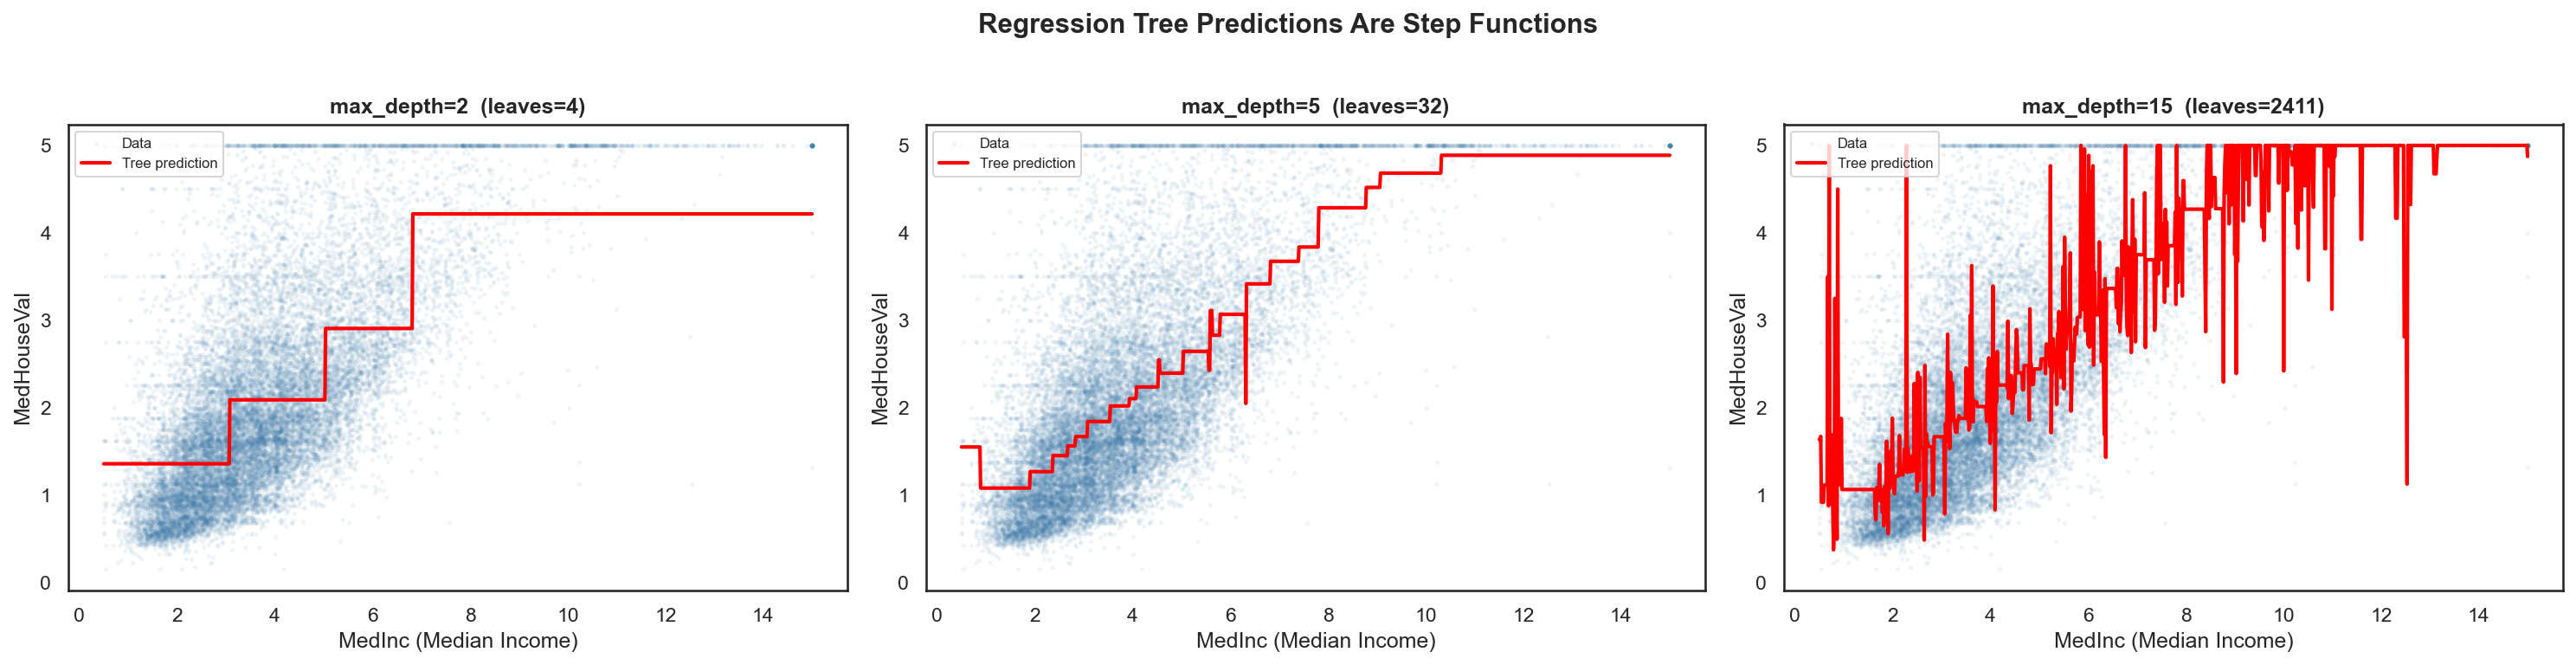

In [8]:
# Train a tree using only MedInc for visualization
X_income = df[["MedInc"]].values

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
depths = [2, 5, 15]

# Create a fine grid for prediction
x_grid = np.linspace(X_income.min(), X_income.max(), 1000).reshape(-1, 1)

for ax, depth in zip(axes, depths):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_income, y)
    y_pred = tree.predict(x_grid)

    ax.scatter(X_income, y, alpha=0.05, s=3, color="steelblue", label="Data")
    ax.plot(x_grid, y_pred, color="red", linewidth=2, label="Tree prediction")
    ax.set_xlabel("MedInc (Median Income)")
    ax.set_ylabel("MedHouseVal")
    ax.set_title(f"max_depth={depth}  (leaves={tree.get_n_leaves()})", fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Regression Tree Predictions Are Step Functions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 What to Notice

- **`max_depth=2`**: Very coarse — only 4 leaves, so the prediction is a rough staircase with 4 flat steps. Underfits the trend.
- **`max_depth=5`**: Captures the main non-linear relationship (rapid price increase for MedInc > 4, saturation at high incomes).
- **`max_depth=15`**: Many narrow steps — starts chasing individual data points (noise), especially in sparse high-income regions.

This is the fundamental trade-off: **more depth = more flexibility = more risk of overfitting**. This connects directly to the pre-pruning discussion in the [theory notes](./11_regression_trees_theory.md).

---

## 6. Tracing a Prediction

Let's trace the exact path the tree takes for a few sample districts:

In [9]:
# Use the depth-3 tree for interpretability
sample_indices = [0, 100, 5000, 15000]

for i in sample_indices:
    sample = X[i]
    true_val = y[i]
    pred_val = reg.predict(sample.reshape(1, -1))[0]

    print(f"--- Sample {i} (true: ${true_val * 100_000:,.0f}, predicted: ${pred_val * 100_000:,.0f}) ---")

    # Get the decision path
    node_indicator = reg.decision_path(sample.reshape(1, -1))
    node_ids = node_indicator.indices

    tree = reg.tree_
    for node_id in node_ids:
        # If leaf node, print the prediction
        if tree.children_left[node_id] == tree.children_right[node_id]:
            leaf_mean = tree.value[node_id].flatten()[0]
            n_samples = tree.n_node_samples[node_id]
            print(f"  → Leaf: predict ${leaf_mean * 100_000:,.0f} (mean of {n_samples:,} samples)")
        else:
            feat = feature_names[tree.feature[node_id]]
            thresh = tree.threshold[node_id]
            val = sample[tree.feature[node_id]]
            direction = "left (Yes)" if val <= thresh else "right (No)"
            print(f"  Node: Is {feat} <= {thresh:.3f}? (value={val:.3f}) → go {direction}")
    print()

--- Sample 0 (true: $452,600, predicted: $456,829) ---
  Node: Is MedInc <= 5.035? (value=8.325) → go right (No)
  Node: Is MedInc <= 6.820? (value=8.325) → go right (No)
  Node: Is MedInc <= 7.815? (value=8.325) → go right (No)
  → Leaf: predict $456,829 (mean of 778 samples)

--- Sample 100 (true: $257,800, predicted: $162,039) ---
  Node: Is MedInc <= 5.035? (value=2.491) → go left (Yes)
  Node: Is MedInc <= 3.074? (value=2.491) → go left (Yes)
  Node: Is AveRooms <= 4.314? (value=3.725) → go left (Yes)
  → Leaf: predict $162,039 (mean of 3,317 samples)

--- Sample 5000 (true: $95,000, predicted: $116,457) ---
  Node: Is MedInc <= 5.035? (value=1.716) → go left (Yes)
  Node: Is MedInc <= 3.074? (value=1.716) → go left (Yes)
  Node: Is AveRooms <= 4.314? (value=4.492) → go right (No)
  → Leaf: predict $116,457 (mean of 4,543 samples)

--- Sample 15000 (true: $140,700, predicted: $187,586) ---
  Node: Is MedInc <= 5.035? (value=3.685) → go left (Yes)
  Node: Is MedInc <= 3.074? (value

Each prediction follows a transparent chain of questions. The final prediction is simply the mean house value of all training districts that ended up in the same leaf.

---

## 7. Feature Importances

Just like classification trees, regression trees rank features by how much they reduce impurity (MSE) across all splits. Features used in high-level splits that partition many samples contribute more.

Feature Importances (from max_depth=10 tree):
   Feature  Importance
    MedInc    0.615085
  AveOccup    0.133784
  Latitude    0.073199
 Longitude    0.065952
  HouseAge    0.045978
  AveRooms    0.037741
Population    0.017646
 AveBedrms    0.010615


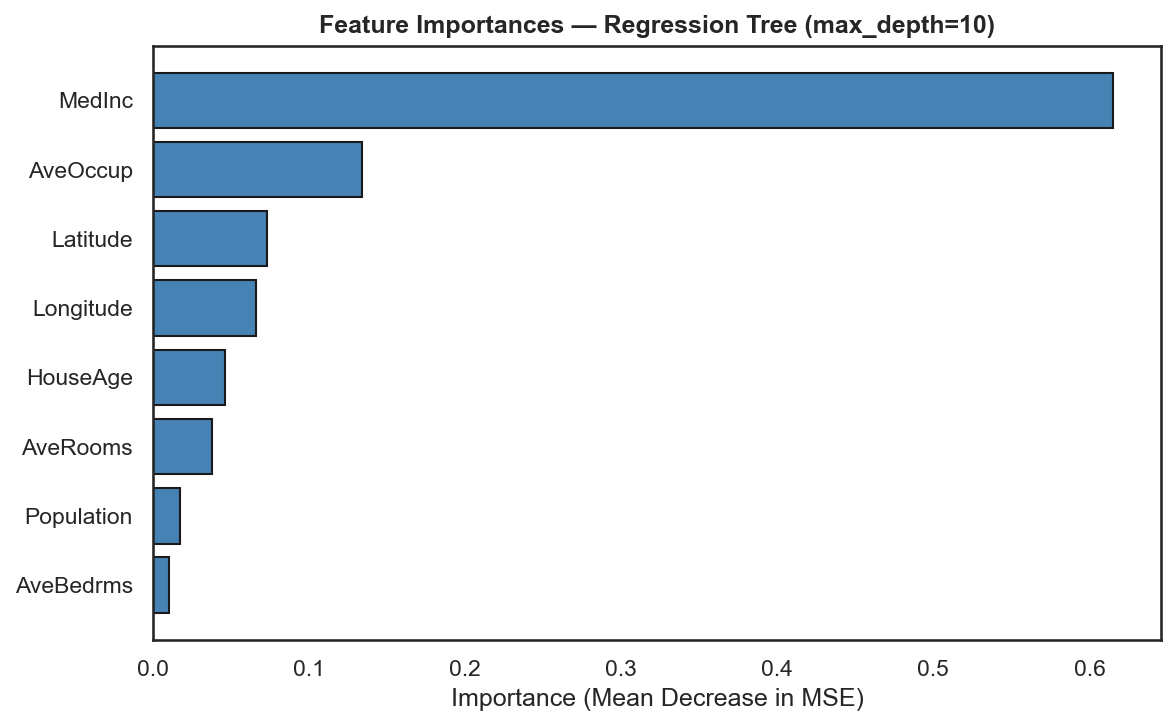

In [10]:
# Build a deeper tree to get more meaningful importances
reg_deep = DecisionTreeRegressor(max_depth=10, random_state=42)
reg_deep.fit(X, y)

importances = reg_deep.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(f"Feature Importances (from max_depth=10 tree):")
print(importance_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue", edgecolor="k")
ax.set_xlabel("Importance (Mean Decrease in MSE)")
ax.set_title("Feature Importances — Regression Tree (max_depth=10)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 📌 What This Tells Us

- **`MedInc` (Median Income)** dominates — consistent with the root split we saw in the tree visualization. Income is by far the strongest predictor of house value.
- **Geographic features** (`Latitude`, `Longitude`) are also important — location matters for housing prices (coastal vs. inland, urban vs. rural).
- **`AveOccup`** (average occupancy) captures overcrowding effects.
- Features like `Population` and `AveBedrms` contribute less.

This is an example of the **implicit feature selection** advantage listed in the theory notes — the tree naturally surfaces the most informative features.

---

## 8. Effect of `max_depth` on the Fit

Let's compare how different depths affect the tree's structure using a 2D slice of the data (MedInc vs. Latitude) to visualize the rectangular partitioning.

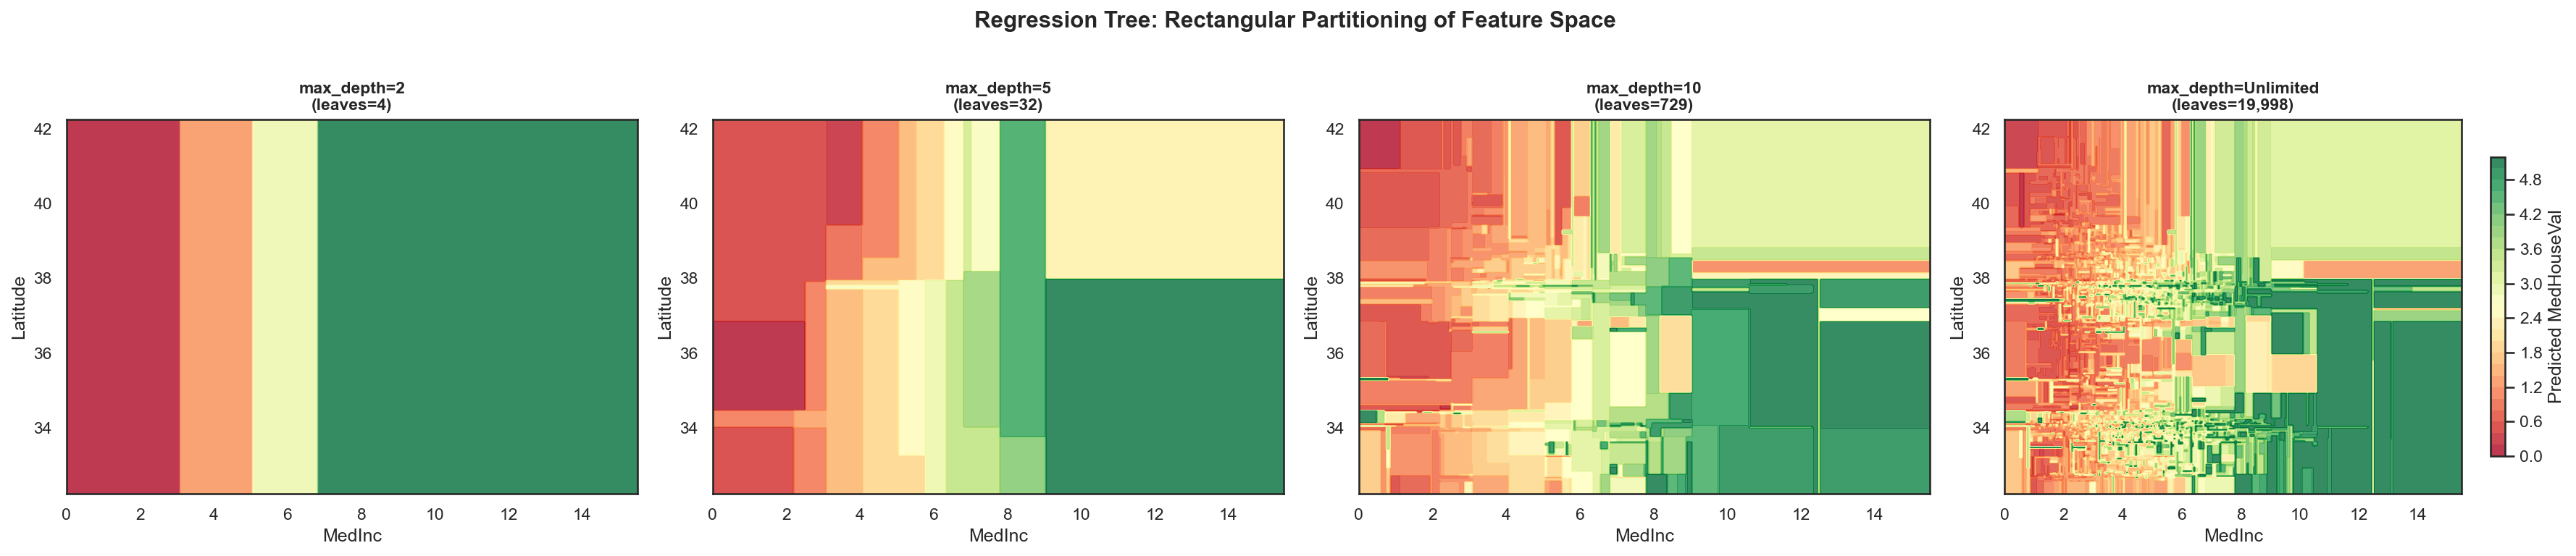

In [11]:
# Use two features for 2D visualization: MedInc and Latitude
X_2d = df[["MedInc", "Latitude"]].values

depths_2d = [2, 5, 10, None]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, depth in zip(axes, depths_2d):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_2d, y)

    # Create mesh grid
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.3, X_2d[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = tree.predict(grid).reshape(xx.shape)
    im = ax.contourf(xx, yy, Z, levels=30, cmap="RdYlGn", alpha=0.8)

    depth_label = depth if depth is not None else "Unlimited"
    ax.set_title(f"max_depth={depth_label}\n(leaves={tree.get_n_leaves():,})", fontsize=11, fontweight="bold")
    ax.set_xlabel("MedInc")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes[-1], label="Predicted MedHouseVal", shrink=0.8)
fig.suptitle("Regression Tree: Rectangular Partitioning of Feature Space", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 Axis-Aligned Rectangles

Notice the same pattern as with classification trees — all boundaries are **axis-aligned** (horizontal or vertical lines). Each split tests a single feature against a threshold.

- **Shallow trees** produce large, coarse blocks (few distinct predicted values).
- **Deep trees** produce many tiny rectangles — each one a very specific region of the feature space with its own predicted mean.
- **Unlimited depth** creates an extremely fragmented grid that memorizes the training data's local patterns.

---

## 9. Limited Extrapolation: A Key Limitation

The theory notes highlight that regression trees have **limited extrapolation** — predictions outside the training range are just the mean of the nearest leaf. Let's demonstrate this concretely.

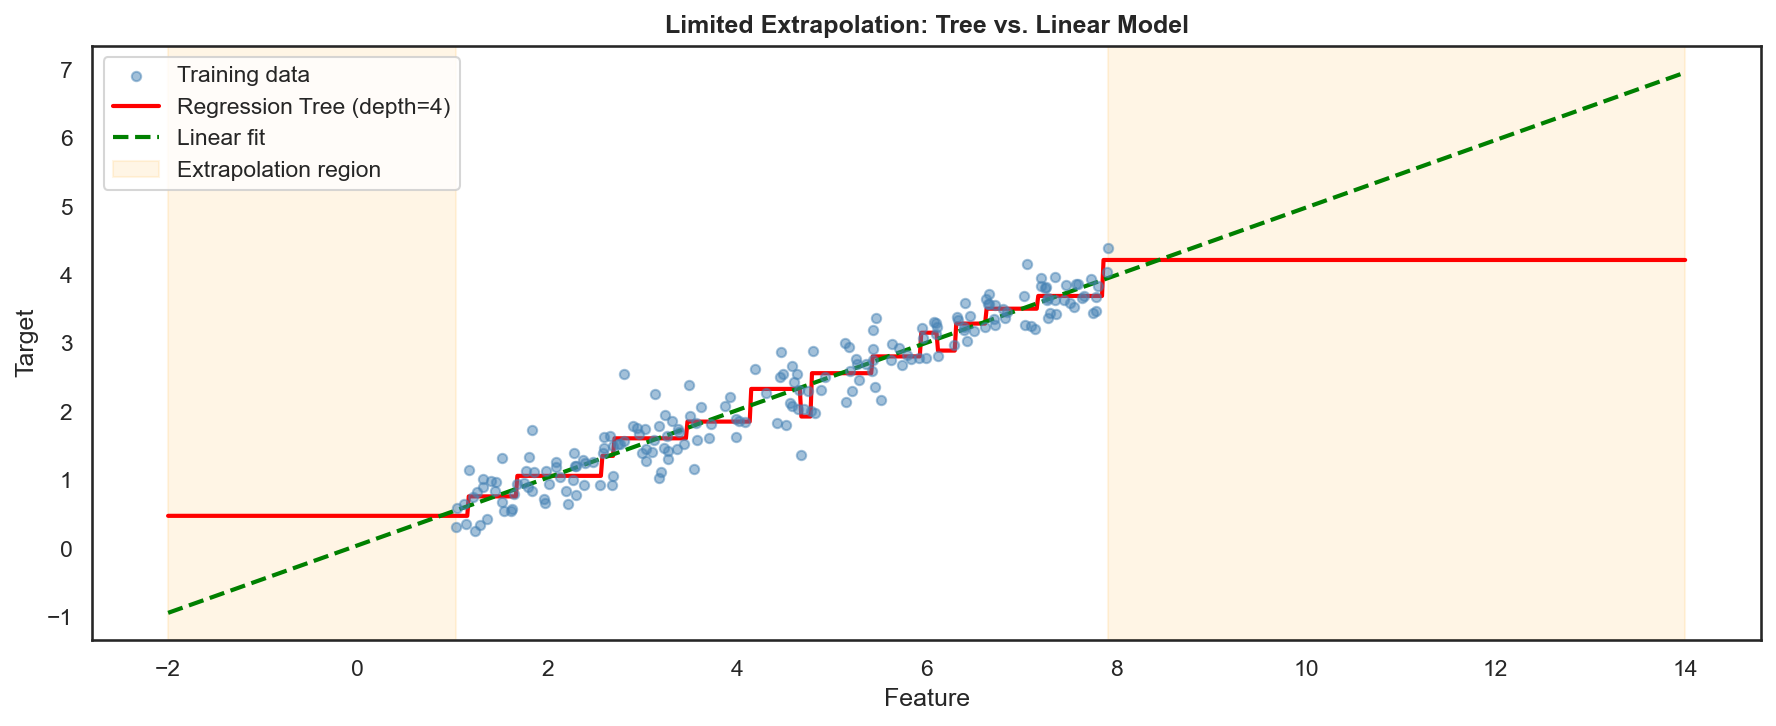

Tree prediction at x=12 (far outside training range): 4.220
Tree prediction at x= 7 (near training edge):        3.507
Tree prediction at x=-1 (below training range):       0.478

→ Outside the training range, the tree simply repeats the prediction of the nearest leaf.
  It cannot extrapolate an upward (or downward) trend beyond what it has seen.


In [12]:
# Demonstrate limited extrapolation with a simple 1D example
np.random.seed(42)

# Generate a simple linear-ish trend
X_demo = np.sort(np.random.uniform(1, 8, 200)).reshape(-1, 1)
y_demo = 0.5 * X_demo.ravel() + np.random.normal(0, 0.3, 200)

# Train a regression tree
tree_demo = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_demo.fit(X_demo, y_demo)

# Predict on a WIDER range — including extrapolation regions
x_wide = np.linspace(-2, 14, 1000).reshape(-1, 1)
y_tree_pred = tree_demo.predict(x_wide)

# Compare with a simple linear fit
from numpy.polynomial.polynomial import polyfit, polyval
coeffs = polyfit(X_demo.ravel(), y_demo, 1)
y_linear_pred = polyval(x_wide.ravel(), coeffs)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(X_demo, y_demo, alpha=0.5, s=20, color="steelblue", label="Training data", zorder=3)
ax.plot(x_wide, y_tree_pred, color="red", linewidth=2, label="Regression Tree (depth=4)")
ax.plot(x_wide, y_linear_pred, color="green", linewidth=2, linestyle="--", label="Linear fit")
ax.axvspan(-2, X_demo.min(), alpha=0.1, color="orange", label="Extrapolation region")
ax.axvspan(X_demo.max(), 14, alpha=0.1, color="orange")
ax.set_xlabel("Feature")
ax.set_ylabel("Target")
ax.set_title("Limited Extrapolation: Tree vs. Linear Model", fontweight="bold")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Tree prediction at x=12 (far outside training range): {tree_demo.predict([[12]])[0]:.3f}")
print(f"Tree prediction at x= 7 (near training edge):        {tree_demo.predict([[7]])[0]:.3f}")
print(f"Tree prediction at x=-1 (below training range):       {tree_demo.predict([[-1]])[0]:.3f}")
print()
print("→ Outside the training range, the tree simply repeats the prediction of the nearest leaf.")
print("  It cannot extrapolate an upward (or downward) trend beyond what it has seen.")

### 📌 Why This Matters

- The **linear model** extrapolates the trend (green dashed line continues rising/falling).
- The **regression tree** goes flat beyond the training range — it can only predict values it has seen during training.
- This is because each leaf prediction is a **mean of training targets**. If no training data exists in a region, the tree defaults to the nearest leaf's mean.

This is one of the key **disadvantages** highlighted in the theory: *"Predictions are averages from training regions; trees do not extrapolate well outside observed ranges."*

---

## 10. Comparing `squared_error` vs. `absolute_error`

The default criterion is `squared_error` (MSE), which we derived in the theory. scikit-learn also offers `absolute_error` (MAE), which is more robust to outliers. Let's see how they compare:

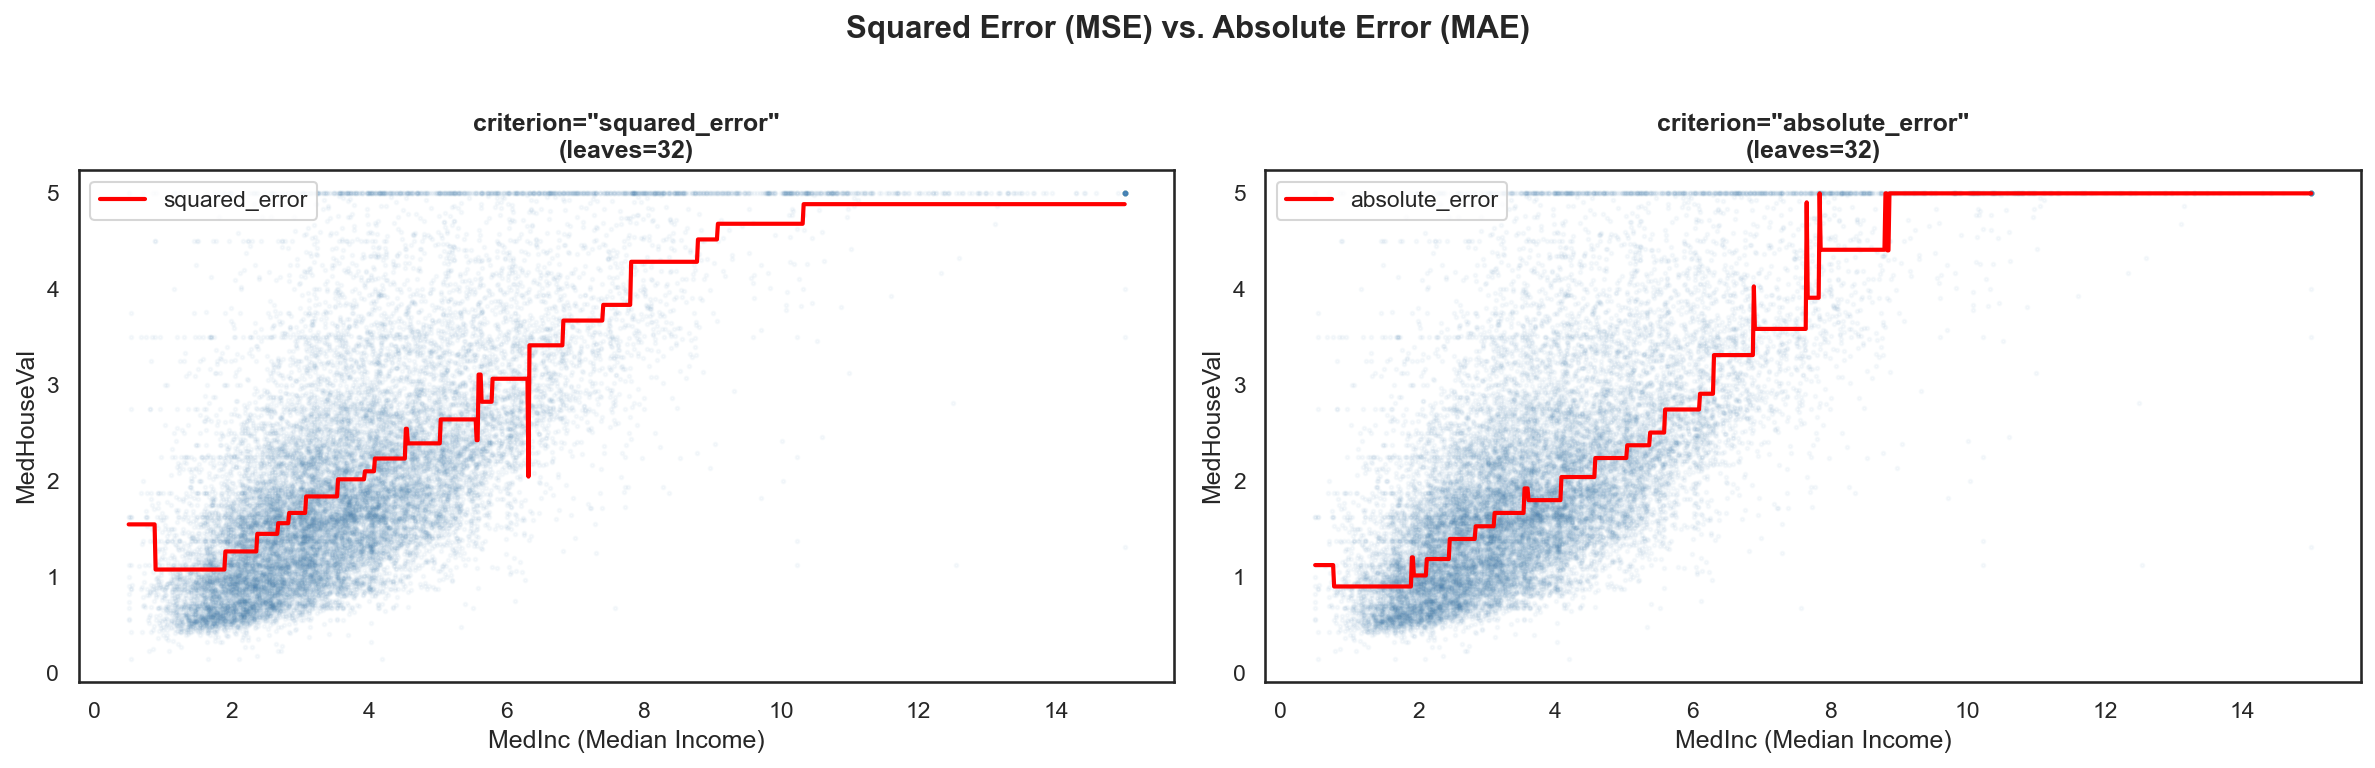

In [13]:
# Compare squared_error vs absolute_error using MedInc feature only
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x_grid_income = np.linspace(X_income.min(), X_income.max(), 1000).reshape(-1, 1)

for ax, criterion in zip(axes, ["squared_error", "absolute_error"]):
    tree = DecisionTreeRegressor(criterion=criterion, max_depth=5, random_state=42)
    tree.fit(X_income, y)
    y_pred = tree.predict(x_grid_income)

    ax.scatter(X_income, y, alpha=0.04, s=3, color="steelblue")
    ax.plot(x_grid_income, y_pred, color="red", linewidth=2, label=f"{criterion}")
    ax.set_xlabel("MedInc (Median Income)")
    ax.set_ylabel("MedHouseVal")
    ax.set_title(f'criterion="{criterion}"\n(leaves={tree.get_n_leaves()})', fontweight="bold")
    ax.legend(loc="upper left")

fig.suptitle("Squared Error (MSE) vs. Absolute Error (MAE)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 Squared Error vs. Absolute Error

- **`squared_error`** (MSE): The default, and what we derived in theory. Leaf predictions are the **mean**. Sensitive to outliers because squaring amplifies large residuals.
- **`absolute_error`** (MAE): Leaf predictions are the **median**. More robust to outliers and skewed distributions. As noted in the theory: *"the median can be used for robustness to outliers (minimizes absolute deviation)."*

For the California Housing data (which has outliers and a capped target), the two criteria may produce slightly different step placements, especially in the high-income tail.

---

## Summary

In this lab, we learned how to use scikit-learn's `DecisionTreeRegressor` for predicting continuous targets. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Load data | California Housing dataset (20,640 districts) | `fetch_california_housing()` |
| No scaling | Trees are invariant to feature scaling | — |
| Build tree | Trained a `DecisionTreeRegressor` | `DecisionTreeRegressor().fit(X, y)` |
| Visualize tree | Plotted the tree structure and decision rules | `plot_tree()`, `export_text()` |
| Step functions | Showed that regression tree predictions are piece-wise constant | `.predict()` on a grid |
| Trace predictions | Followed the decision path for individual samples | `.decision_path()` |
| Feature importance | Identified MedInc as the dominant predictor | `.feature_importances_` |
| Depth comparison | Visualized underfitting → overfitting across depths | `max_depth` |
| Extrapolation | Demonstrated trees cannot extrapolate beyond training range | Compared to linear model |
| Criteria | Compared `squared_error` (mean) vs. `absolute_error` (median) | `criterion` |

The key takeaways are:

1. **Regression trees predict the mean target value** of the training samples in each leaf region.
2. **Predictions are piece-wise constant** (step functions) — more leaves = finer steps.
3. **`max_depth` controls the underfitting/overfitting trade-off** — the most important hyperparameter.
4. **Trees cannot extrapolate** — predictions outside the training range are flat.
5. **Feature importances** are built-in and reveal which features drive the splits.
6. **No feature scaling needed** — just like classification trees.

---

**Next:** [SVM Theory](./14_support_vector_machines_theory.md)